,user_id,weight,height,salads_per_week,veggies_fruits_per_day,healthy_diet,aerobic_per_week,sports_per_week,current_smoking,survey.month,prob_cancer,cancer_category
0,55,140.0,69.0,0.0,NaN,Below average,2.0,0.0,Never,2008.09,0.066120,very low
1,36,150.0,67.0,2.0,1.0,Below average,3.0,3.0,Never,2008.09,0.366939,low
2,39,105.0,66.0,0.0,2.0,Average,1.0,0.0,Never,2008.09,0.805540,very high
3,37,220.0,77.0,2.0,5.0,Very healthy,5.0,5.0,Never,2008.09,0.537907,medium
4,72,135.0,62.0,0.0,1.0,Unhealthy,0.0,0.0,Never,2008.09,0.098464,very low
5,11,180.0,69.0,0.0,1.0,Unhealthy,5.0,0.0,Never,2008.09,0.321663,low
6,63,0.0,2801.0,7.0,0.0,Very unhealthy,0.0,1.0,0,2008.09,0.520753,medium
7,21,240.0,75.0,0.0,1.0,Unhealthy,1.0,0.0,Never,2008.09,0.580648,medium
8,59,170.0,72.0,3.0,3.0,Average,5.0,5.0,Never,2008.09,0.507444,medium
9,47,145.0,68.0,1.0,3.0,Healthy,3.0,0.0,Never,2008.09,0.083572,very low


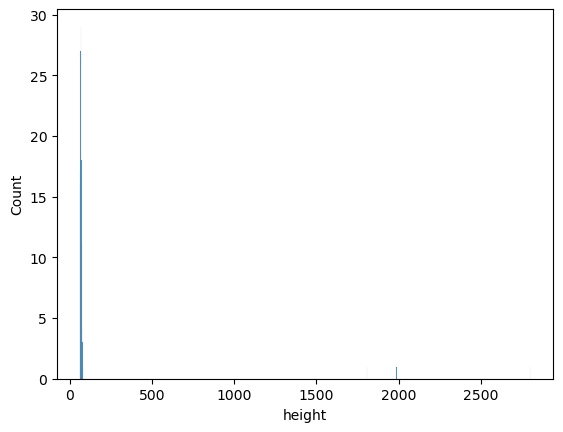

,user_id,weight,height,salads_per_week,veggies_fruits_per_day,healthy_diet,aerobic_per_week,sports_per_week,current_smoking,survey.month,prob_cancer,cancer_category
0,55,69.0,140.0,0.0,NaN,Below average,2.0,0.0,Never,2008.09,0.066120,very low
1,36,67.0,150.0,2.0,1.0,Below average,3.0,3.0,Never,2008.09,0.366939,low
2,39,66.0,105.0,0.0,2.0,Average,1.0,0.0,Never,2008.09,0.805540,very high
3,37,77.0,220.0,2.0,5.0,Very healthy,5.0,5.0,Never,2008.09,0.537907,medium
4,72,62.0,135.0,0.0,1.0,Unhealthy,0.0,0.0,Never,2008.09,0.098464,very low


Never              363
Once in a while     10
0                    1
5                    1
2                    1
Some days            1
Name: current_smoking, dtype: int64


,user_id,weight,height,salads_per_week,veggies_fruits_per_day,healthy_diet,aerobic_per_week,sports_per_week,current_smoking,survey.month,prob_cancer,cancer_category
6,63,2801.0,0.0,7.0,0.0,Very unhealthy,0.0,1.0,0,2008.09,0.520753,medium
35,61,1985.0,0.0,9.0,1.0,NaN,0.0,1.0,5,2008.09,0.190994,very low
50,5,1805.0,0.0,9.0,2.0,Unhealthy,0.0,2.0,2,2008.09,0.387530,low


Never              364
Once in a while     10
5                    1
2                    1
Some days            1
Name: current_smoking, dtype: int64
Never              364
Once in a while     10
Some days            1
Name: current_smoking, dtype: int64


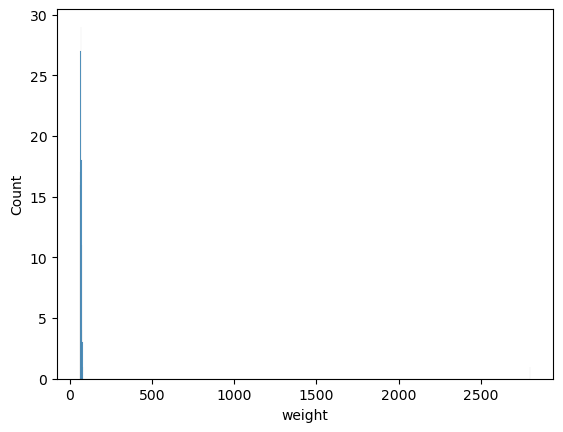

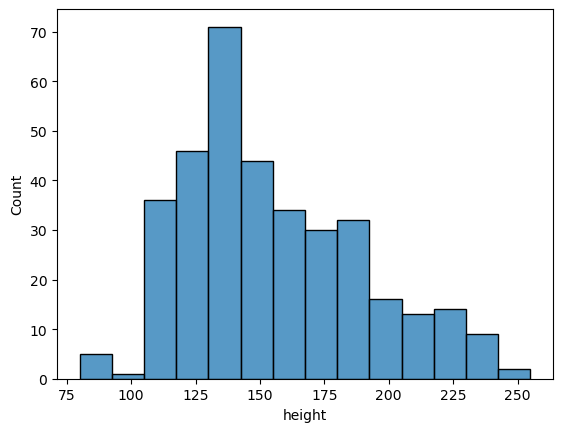

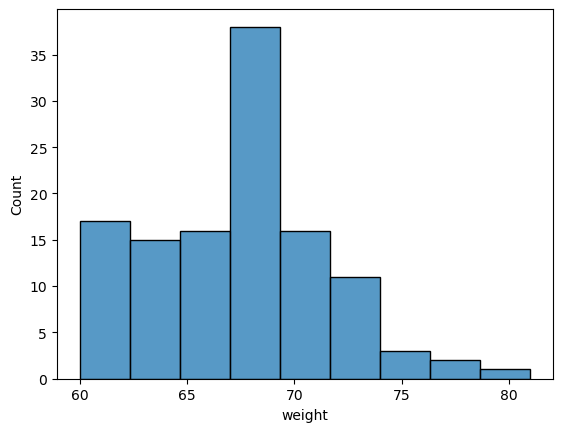

KNeighborsClassifier()

Confusion Matrix:
 [[ 1  6  3  3  7  0]
 [ 3  3  5  2  5  0]
 [ 5  9  3  2  3  0]
 [ 1 11  2  1  8  0]
 [ 2  8  5  2  1  0]
 [ 1  2  1  1  0  0]]
R2 Score: -1.2072721448021784
Accuracy: 0.08490566037735849


prob_cancer               1.000000
aerobic_per_week          0.067885
sports_per_week           0.056539
healthy_diet              0.047565
salads_per_week           0.046060
veggies_fruits_per_day    0.012832
current_smoking          -0.013591
height                   -0.024305
weight                   -0.034942
Name: prob_cancer, dtype: float64

<class 'numpy.int64'>


KNeighborsClassifier()

Confusion Matrix:
 [[ 5  5  8  2  0]
 [ 2  0 13  2  1]
 [ 4  7 15  1  0]
 [ 4  7  7  3  2]
 [ 4  3 10  0  1]]
R2 Score: -0.6322041355037396
Accuracy: 0.22641509433962265


In [24]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#____________________________ part a ______________________________#
import pandas as pd
import numpy as np

data = pd.read_csv('cancer.csv', sep='\t')
num_bins = 5
bin_width = (data['prob_cancer'].max() - data['prob_cancer'].min()) / num_bins
bin_edges = [data['prob_cancer'].min() + i*bin_width for i in range(num_bins+1)]
bin_labels = ['very low', 'low', 'medium', 'high', 'very high']
data['cancer_category'] = pd.cut(data['prob_cancer'], bins=bin_edges, labels=bin_labels)
data.head(10)

#____________________________ part b ______________________________#
import matplotlib.pyplot as plt
import seaborn as sns

plot=sns.histplot(data['height'],kde=False)
plt.show()
#data['height'].min()
#data['height'].max()
data[['height', 'weight']] = data[['weight', 'height']].values
data.head()
#data = data.dropna()

#____________________________ part c ______________________________#

print(data['current_smoking'].value_counts())

new_df = data[data['current_smoking'].apply(lambda x: str(x).isdigit())]
new_df.head()

# Drop rows with missing data in 'current_smoking' column and replace '0' with 'Never'
data = data.dropna(subset=['current_smoking'])
data['current_smoking'] = data['current_smoking'].replace('0', 'Never')
print(data['current_smoking'].value_counts())

#a function to delete non-categorical values from categorical attributes
def clear_categorical_attr(df,attr):
    '''
    def is_int(x):
        return isinstance(x, int)

    # create boolean mask to find integer values in categorical columns
    mask1 = df[attr].apply(is_int)
    '''
    # create boolean mask to find str values that can be converted to integers in categorical columns 
    mask = df[attr].astype(str).str.isdigit()
    
    return df.loc[~mask]

# delete non-categorical values from categorical attributes
for attr in list(data.columns):
    if attr== 'healthy_diet' or attr=='current_smoking':
        data=clear_categorical_attr(data,attr)

print(data['current_smoking'].value_counts())

#____________________________ part d ______________________________#

plot=sns.histplot(data['weight'],kde=False)
plt.show()

data = data.drop(data[(data['height'] < 50) | (data['height'] > 300)].index)

def delete_outlier(df,attr):
    Q1=df[attr].quantile(0.25)
    Q3=df[attr].quantile(0.75)
    IQR=Q3-Q1
    lower_limit=Q1-1.5*IQR
    upper_limit=Q3+1.5*IQR
    return df[(df[attr]>=lower_limit)&(df[attr]<=upper_limit)]

data=delete_outlier(data,'height')
#data=delete_outlier(data,'weight')

_=plt.figure()
plot=sns.histplot(data['height'],kde=False)
plt.show()

_=plt.figure()
plot=sns.histplot(data['weight'],kde=False)
plt.show()

data = data.fillna(data.mean(numeric_only=True))
#pd.set_option('display.max_rows', None)   # Show all rows
#pd.set_option('display.max_columns', None)   # Show all columns
#print(data['height'].value_counts())

#____________________________ part e ______________________________#

cancer_data=data.copy()
data.drop(columns=['user_id', 'prob_cancer', 'survey.month'],inplace=True)
#data=data.astype('float64')
#data.corr(numeric_only=True)['cancer_category'].sort_values(ascending=False) #correlation should be calculated for regression
#data.to_csv('my_data.csv', index=False)
#print(type(data['cancer_category'][1]))

#____________________________ part f ______________________________#
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

le = LabelEncoder()
for attr in ['healthy_diet', 'current_smoking', 'cancer_category']:
    data[attr] = le.fit_transform(data[attr])

X = data.drop('cancer_category', axis=1)
y = data['cancer_category']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardizing the data
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

#____________________________ part g ______________________________#
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_std, y_train)
y_pred = knn.predict(X_test_std)

#____________________________ part h ______________________________#
from sklearn.metrics import confusion_matrix, r2_score, accuracy_score

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#____________________________ part i ______________________________#
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler

#cancer_data.head()
cancer_data_corr=cancer_data.copy()
cancer_data_corr.drop(columns=['user_id', 'cancer_category', 'survey.month'],inplace=True)

enc1=OrdinalEncoder()
for attr in ['healthy_diet', 'current_smoking']:
    cancer_data_corr[[attr]] = enc1.fit_transform(cancer_data_corr[[attr]])
cancer_data_corr=cancer_data_corr.astype('float64')
cancer_data_corr.corr(numeric_only=True)['prob_cancer'].sort_values(ascending=False)

new_data=pd.DataFrame({'aerobic_per_week': cancer_data['aerobic_per_week'], 
                       'sports_per_week': cancer_data['sports_per_week'], 
                       'cancer_category': cancer_data['cancer_category']})
#new_data.head()
new_data[['cancer_category']] = enc1.fit_transform(new_data[['cancer_category']])
new_data = new_data.fillna(data.mean(numeric_only=True))
#new_data.head()
#print(type(new_data['cancer_category'][1]))
new_data['cancer_category']=new_data['cancer_category'].astype('int')
print(type(new_data['cancer_category'][1]))
#new_data.head()

X = new_data.drop('cancer_category', axis=1)
y = new_data['cancer_category']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardizing the data
scaler = MinMaxScaler()
X_train_minmax = scaler.fit_transform(X_train)
X_test_minmax = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_minmax, y_train)
y_pred = knn.predict(X_test_minmax)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
